I051 Siddhant ATML Lab 5

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [14]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
batch_size        = 64
image_size        = 64      # STL-10 is 96×96, resized to 64×64
channels          = 3       # RGB
z_dim             = 100     # Latent space dimension
num_epochs        = 2
lr                = 0.00005 # Recommended LR from WGAN paper
critic_iterations = 5       # Train critic 5× per generator step
weight_clip       = 0.01    # Lipschitz constraint via weight clipping
features_gen      = 64
features_critic   = 64

ran only 2 epochs because of the computational issue, running the epochs was time consuming and more epochs were getting computationally very expensive.

In [15]:
os.makedirs("generated_images", exist_ok=True)
os.makedirs("saved_models",     exist_ok=True)

In [16]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # scale to [-1, 1]
])

# Downloads from http://ai.stanford.edu/~acoates/stl10/
dataset = torchvision.datasets.STL10(
    root="./data",
    split="unlabeled",   # 100,000 images
    transform=transform,
    download=True
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
print(f"Dataset size : {len(dataset):,} images")
print(f"Batches/epoch: {len(loader):,}")

Dataset size : 100,000 images
Batches/epoch: 1,563


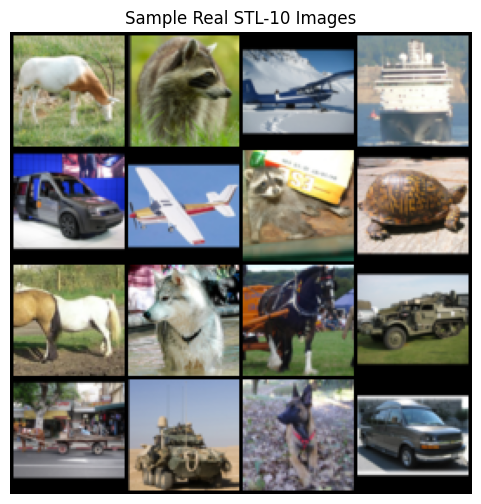

In [17]:
# Preview a batch of real images
real_batch, _ = next(iter(loader))
grid = torchvision.utils.make_grid(real_batch[:16], normalize=True, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Sample Real STL-10 Images")
plt.show()

## Model Architecture
- **Generator**: latent vector (100×1×1) → RGB image (3×64×64) via transposed convolutions
- **Critic**: RGB image → scalar score (no sigmoid — raw Wasserstein score)
- Key WGAN change: Critic has **no sigmoid**, loss is Earth Mover distance

In [18]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels, features_g):
        super().__init__()
        self.net = nn.Sequential(
            # z: z_dim×1×1
            self._block(z_dim,          features_g * 16, 4, 1, 0),  # →  4×4
            self._block(features_g * 16, features_g * 8,  4, 2, 1),  # →  8×8
            self._block(features_g * 8,  features_g * 4,  4, 2, 1),  # → 16×16
            self._block(features_g * 4,  features_g * 2,  4, 2, 1),  # → 32×32
            nn.ConvTranspose2d(features_g * 2, channels, 4, 2, 1),   # → 64×64
            nn.Tanh()
        )

    def _block(self, in_ch, out_ch, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True)
        )

    def forward(self, x):
        return self.net(x)

In [19]:
class Critic(nn.Module):
    def __init__(self, channels, features_d):
        super().__init__()
        self.net = nn.Sequential(
            # Input: channels×64×64
            nn.Conv2d(channels,       features_d,      4, 2, 1, bias=False),  # → 32×32
            nn.LeakyReLU(0.2, inplace=True),
            self._block(features_d,      features_d * 2,  4, 2, 1),  # → 16×16
            self._block(features_d * 2,  features_d * 4,  4, 2, 1),  # →  8×8
            self._block(features_d * 4,  features_d * 8,  4, 2, 1),  # →  4×4
            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=False)        # →  1×1 score
            # NO sigmoid — raw Wasserstein score
        )

    def _block(self, in_ch, out_ch, k, s, p):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [20]:
def weights_init(m):
    """DCGAN-style weight initialisation — helps stable convergence."""
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [21]:
gen    = Generator(z_dim, channels, features_gen).to(device)
critic = Critic(channels, features_critic).to(device)

gen.apply(weights_init)
critic.apply(weights_init)

print(f"Generator parameters : {sum(p.numel() for p in gen.parameters()):,}")
print(f"Critic parameters    : {sum(p.numel() for p in critic.parameters()):,}")

Generator parameters : 12,658,435
Critic parameters    : 2,765,568


In [22]:
# RMSprop as specified in the original WGAN paper (Adam can cause instability)
opt_gen    = optim.RMSprop(gen.parameters(),    lr=lr)
opt_critic = optim.RMSprop(critic.parameters(), lr=lr)

fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

## Training Loop
**Three WGAN-specific rules:**
1. Critic trained `critic_iterations` (5) times per generator step
2. Critic loss = −(mean score on real − mean score on fake) → maximise Wasserstein distance
3. Weight clipping to `[−0.01, 0.01]` enforces Lipschitz constraint

In [23]:
gen_losses    = []
critic_losses = []

for epoch in range(num_epochs):
    for batch_idx, (real, _) in enumerate(loader):
        real           = real.to(device)
        cur_batch_size = real.shape[0]

        # ── Train Critic ─────────────────────────────────────────────────────
        for _ in range(critic_iterations):
            noise       = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
            fake        = gen(noise).detach()          # no grad through G here

            critic_real = critic(real)
            critic_fake = critic(fake)

            # Wasserstein loss (negate because we minimise)
            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake))

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

            # ── Weight Clipping (Lipschitz constraint) ─────────────────────
            for p in critic.parameters():
                p.data.clamp_(-weight_clip, weight_clip)

        # ── Train Generator ───────────────────────────────────────────────────
        noise    = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
        fake     = gen(noise)
        loss_gen = -torch.mean(critic(fake))           # maximise critic score on fake

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        gen_losses.append(loss_gen.item())
        critic_losses.append(loss_critic.item())

        if batch_idx % 200 == 0:
            print(
                f"Epoch [{epoch+1:02d}/{num_epochs}]  "
                f"Batch [{batch_idx:04d}/{len(loader)}]  "
                f"Critic Loss: {loss_critic.item():+.4f}  "
                f"Gen Loss:    {loss_gen.item():+.4f}"
            )

    # Save image grid after each epoch
    with torch.no_grad():
        fake_epoch = gen(fixed_noise).detach().cpu()
        torchvision.utils.save_image(
            fake_epoch,
            f"generated_images/epoch_{epoch+1:02d}.png",
            normalize=True, nrow=8
        )
    print(f"  → Saved generated_images/epoch_{epoch+1:02d}.png")

print("\n✓ Training complete!")

Epoch [01/2]  Batch [0000/1563]  Critic Loss: -0.0254  Gen Loss:    +0.0175
Epoch [01/2]  Batch [0200/1563]  Critic Loss: -1.2908  Gen Loss:    +0.6453
Epoch [01/2]  Batch [0400/1563]  Critic Loss: -1.3631  Gen Loss:    +0.6795
Epoch [01/2]  Batch [0600/1563]  Critic Loss: -1.3737  Gen Loss:    +0.6822
Epoch [01/2]  Batch [0800/1563]  Critic Loss: -1.3193  Gen Loss:    +0.6489
Epoch [01/2]  Batch [1000/1563]  Critic Loss: -1.3497  Gen Loss:    +0.6649
Epoch [01/2]  Batch [1200/1563]  Critic Loss: -1.3205  Gen Loss:    +0.6578
Epoch [01/2]  Batch [1400/1563]  Critic Loss: -1.1751  Gen Loss:    -0.2680
  → Saved generated_images/epoch_01.png
Epoch [02/2]  Batch [0000/1563]  Critic Loss: -1.3249  Gen Loss:    +0.6475
Epoch [02/2]  Batch [0200/1563]  Critic Loss: -1.3310  Gen Loss:    +0.6364
Epoch [02/2]  Batch [0400/1563]  Critic Loss: -1.3182  Gen Loss:    +0.6432
Epoch [02/2]  Batch [0600/1563]  Critic Loss: -1.3113  Gen Loss:    +0.6326
Epoch [02/2]  Batch [0800/1563]  Critic Loss: -1

In [24]:
# Save models
torch.save(gen.state_dict(),    "saved_models/generator_stl10.pth")
torch.save(critic.state_dict(), "saved_models/critic_stl10.pth")
print("Models saved to saved_models/")

Models saved to saved_models/


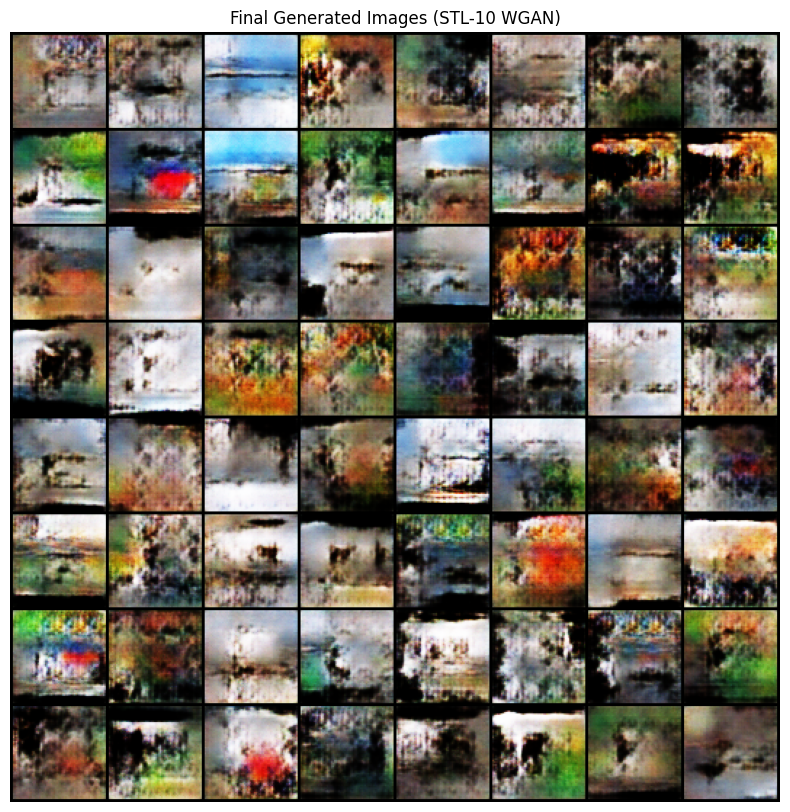

In [25]:
# Final generated image grid
gen.eval()
with torch.no_grad():
    final_fake = gen(torch.randn(64, z_dim, 1, 1).to(device)).cpu()

torchvision.utils.save_image(
    final_fake, "generated_images/final_generated_stl10.png",
    normalize=True, nrow=8
)

grid = torchvision.utils.make_grid(final_fake, normalize=True, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Final Generated Images (STL-10 WGAN)")
plt.show()

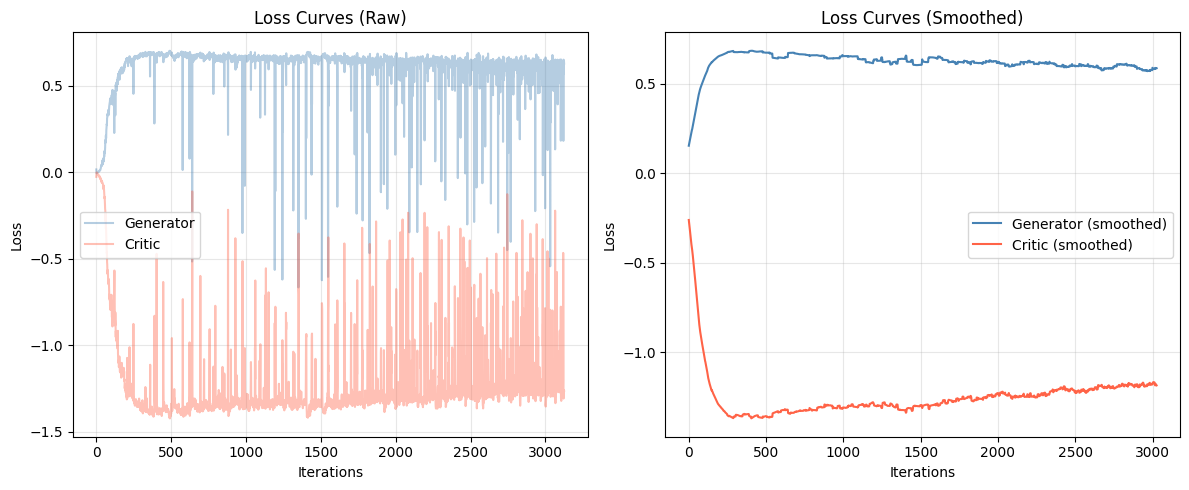

In [26]:
# Loss curves
def smooth(arr, w=100):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gen_losses,    alpha=0.4, color="steelblue", label="Generator")
plt.plot(critic_losses, alpha=0.4, color="tomato",    label="Critic")
plt.title("Loss Curves (Raw)")
plt.xlabel("Iterations"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(smooth(gen_losses),    color="steelblue", label="Generator (smoothed)")
plt.plot(smooth(critic_losses), color="tomato",    label="Critic (smoothed)")
plt.title("Loss Curves (Smoothed)")
plt.xlabel("Iterations"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("generated_images/loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

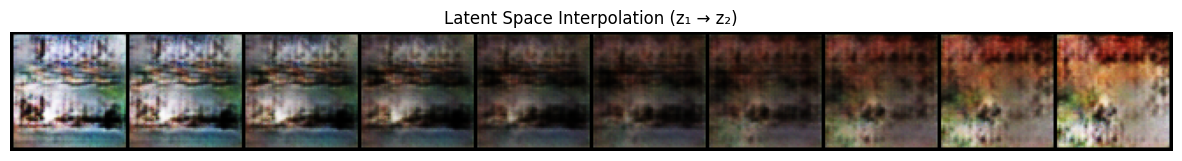

In [27]:
# Latent Space Interpolation — smooth walk between two random points in Z
gen.eval()
z1 = torch.randn(1, z_dim, 1, 1).to(device)
z2 = torch.randn(1, z_dim, 1, 1).to(device)

interp_imgs = []
for alpha in np.linspace(0, 1, 10):
    z = (1 - alpha) * z1 + alpha * z2
    with torch.no_grad():
        interp_imgs.append(gen(z).cpu().squeeze(0))

grid = torchvision.utils.make_grid(torch.stack(interp_imgs), normalize=True, nrow=10)
plt.figure(figsize=(15, 2))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Latent Space Interpolation (z₁ → z₂)")
plt.show()

## Gradio Demo

In [28]:
!pip install gradio -q

import gradio as gr
import torchvision.utils as vutils
from PIL import Image

gen_demo = Generator(z_dim, channels, features_gen).to(device)
gen_demo.load_state_dict(torch.load("saved_models/generator_stl10.pth", map_location=device))
gen_demo.eval()

def generate_images(num_images, seed):
    torch.manual_seed(int(seed))
    noise = torch.randn(int(num_images), z_dim, 1, 1).to(device)
    with torch.no_grad():
        fake = gen_demo(noise).cpu()
    grid = vutils.make_grid(fake, nrow=min(int(num_images), 4), normalize=True, padding=2)
    arr  = grid.mul(255).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(arr)

gr.Interface(
    fn=generate_images,
    inputs=[
        gr.Slider(1, 16, step=1, value=8,  label="Number of Images"),
        gr.Slider(0, 9999, step=1, value=42, label="Random Seed")
    ],
    outputs=gr.Image(type="pil", label="Generated Images"),
    title="WGAN on STL-10",
    description="Generate STL-10-like images using a Wasserstein GAN."
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://13ee835217beb363a3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
